# **Transfer Learning**

In [107]:
import tensorflow as tf
from tensorflow import keras
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras import Sequential
from keras.layers import *
from keras.optimizers import RMSprop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [108]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [109]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [110]:
os.listdir("/kaggle/input/dogsvscats")


['test', 'train', 'catsvsdogs']

In [111]:
import os
print(os.listdir("/kaggle/input/dogsvscats/train"))
print(os.listdir("/kaggle/input/dogsvscats/test"))

['dogs', 'cats']
['dogs', 'cats']


In [112]:
# Generators

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/dogsvscats/train",
    image_size=(150, 150),
    batch_size=32,
    labels = 'inferred',
    label_mode = 'int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/dogsvscats/test",
    image_size = (150, 150),
    batch_size = 32,
    labels = 'inferred',
    label_mode = 'int'
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## **Using Feature Extraction**

In [53]:
conv_base = VGG16(weights = 'imagenet', include_top = False, input_shape= (150, 150, 3))

In [54]:
model = Sequential()

In [55]:
model.add(conv_base)

In [56]:
model.add(Flatten())

In [57]:
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [58]:
conv_base.trainable = False

In [59]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,771,713 (60.16 MB)

 Trainable params: 1,057,025 (4.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [60]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [61]:
history= model.fit(train_ds, epochs = 10, validation_data= test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 166ms/step - accuracy: 0.9282 - loss: 0.4423 - val_accuracy: 0.9306 - val_loss: 0.2979
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9631 - loss: 0.1042 - val_accuracy: 0.9398 - val_loss: 0.2253
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9737 - loss: 0.0850 - val_accuracy: 0.9462 - val_loss: 0.2546
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9760 - loss: 0.0782 - val_accuracy: 0.9452 - val_loss: 0.2757
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 156ms/step - accuracy: 0.9847 - loss: 0.0533 - val_accuracy: 0.9458 - val_loss: 0.3264
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.9814 - loss: 0.0635 - val_accuracy: 0.9444 - val_loss: 0.2751
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9494 - val_loss: 0.3168
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9893 - loss:

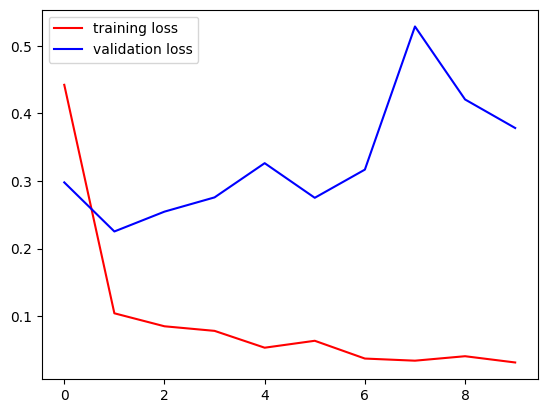

In [62]:
plt.plot(history.history['loss'], color = 'red', label = 'training loss')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation loss')
plt.legend()
plt.show()

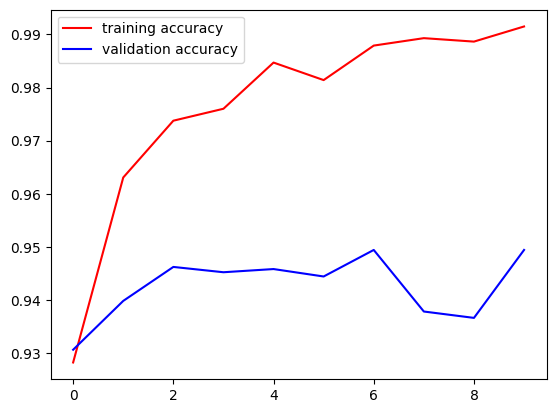

In [63]:
plt.plot(history.history['accuracy'], color = 'red', label = 'training accuracy')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation accuracy')
plt.legend()
plt.show()

## **Using Fine Tuning**

In [113]:
conv_base2 = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

In [114]:
conv_base2.trainable = True

set_trainable = False

for layer in conv_base2.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base2.layers:
  print(layer.name, layer.trainable)

input_layer_16 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [115]:
conv_base2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [116]:
model2 = Sequential()

In [117]:
model2.add(conv_base2)
model2.add(Flatten())
model2.add(Dense(256, activation = 'relu'))
model2.add(Dense(1, activation= 'sigmoid'))

In [119]:
model2.compile(loss = 'binary_crossentropy', optimizer = RMSprop(learning_rate = 1e-5), metrics = ['accuracy'])

In [120]:
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [121]:
history2 = model2.fit(train_ds, epochs = 10, validation_data = test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 118s 184ms/step - accuracy: 0.8986 - loss: 0.2372 - val_accuracy: 0.9362 - val_loss: 0.1601
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 175ms/step - accuracy: 0.9477 - loss: 0.1329 - val_accuracy: 0.9490 - val_loss: 0.1309
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9638 - loss: 0.0931 - val_accuracy: 0.9276 - val_loss: 0.1778
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9761 - loss: 0.0663 - val_accuracy: 0.9506 - val_loss: 0.1224
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9863 - loss: 0.0448 - val_accuracy: 0.9542 - val_loss: 0.1223
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9913 - loss: 0.0300 - val_accuracy: 0.9540 - val_loss: 0.1278
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 172ms/step - accuracy: 0.9953 - loss: 0.0196 - val_accuracy: 0.9508 - val_loss: 0.1494
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9970 -

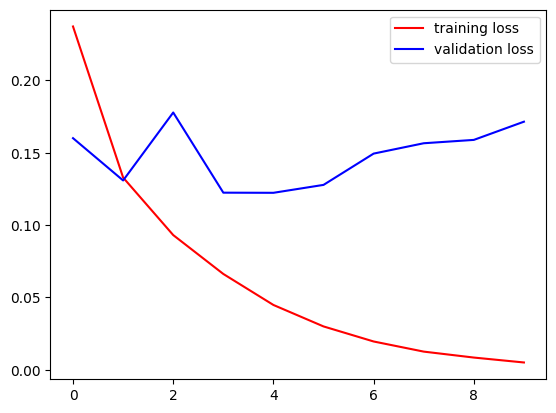

In [125]:
plt.plot(history2.history['loss'], color = 'red', label = 'training loss')
plt.plot(history2.history['val_loss'], color = 'blue', label = 'validation loss')
plt.legend()
plt.show()

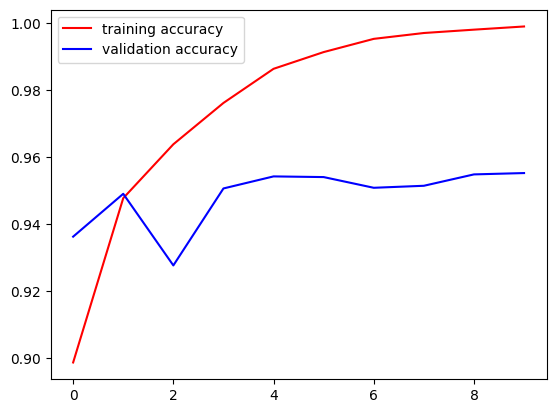

In [126]:
plt.plot(history2.history['accuracy'], color = 'red', label = 'training accuracy')
plt.plot(history2.history['val_accuracy'], color = 'blue', label = 'validation accuracy')
plt.legend()
plt.show()